# 06 Groupby, Concat, and Raggedness

Collections of trajectories often have unequal valid lengths and need grouped summaries or concatenation along batch/sequence roles.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import tal

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Create a ragged AO

The value `999.0` is padding. `group_size` declares which prefix samples are valid for each trial.


In [2]:
trial = xr.DataArray(['A', 'B', 'C'], dims=['trial'])
sample = xr.DataArray(np.arange(8), dims=['sample'])

y = np.full((3, 8), 999.0)
y[0, :8] = np.linspace(0.0, 100.0, 8)
y[1, :5] = np.linspace(1.0, 100.0, 5)
y[2, :3] = np.linspace(2.0, 100.0, 3)

ds = xr.Dataset(
    {'y': (('trial', 'sample'), y)},
    coords={
        'trial': trial,
        'sample': sample,
        'group_size': ('trial', np.array([8, 5, 3], dtype='int64')),
        'outcome': ('trial', np.array(['pass', 'fail', 'pass'], dtype=object)),
        'time': (('trial', 'sample'), np.tile(np.linspace(0.0, 1.0, 8), (trial.size, 1))),
    },
)

ao = tal.AnalysisObject.from_data(
    ds,
    sequence_dim='sample',
    batch_dims=['trial'],
    core_dims=[],
    param_coord='time',
    sequence_size_coord='group_size',
)
ao


## Ragged-safe reduction

This comparison is the reason validity metadata exists: padding should not contaminate reductions.


In [3]:
naive_padded_mean = ao.as_dataset()['y'].mean(dim='sample')
tal_mean = ao.mean(dim='sample').as_dataset()['y']
mean_comparison = xr.Dataset(
    {
        'naive_including_padding': naive_padded_mean,
        'tal_ragged_safe': tal_mean,
        'difference': naive_padded_mean - tal_mean,
    }
)

mean_comparison


<xarray.Dataset> Size: 132B
Dimensions:                  (trial: 3)
Coordinates:
  * trial                    (trial) <U1 12B 'A' 'B' 'C'
    group_size               (trial) int64 24B 8 5 3
    outcome                  (trial) object 24B 'pass' 'fail' 'pass'
Data variables:
    naive_including_padding  (trial) float64 24B 50.0 406.2 643.5
    tal_ragged_safe          (trial) float64 24B 50.0 50.5 51.0
    difference               (trial) float64 24B 0.0 355.7 592.5

## Plot naive vs TAL means

The chart checks whether padded samples influenced the summary.


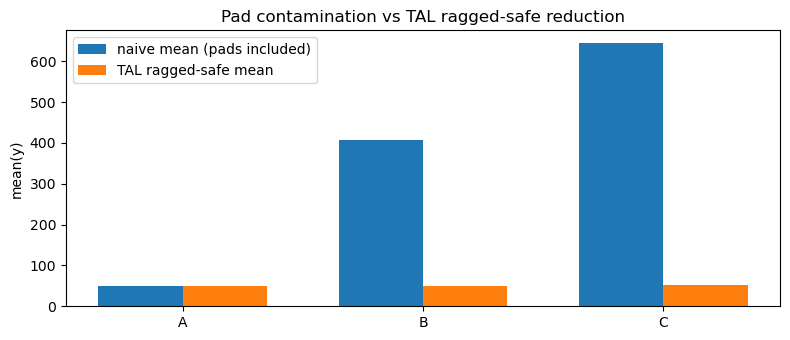

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Plot skipped: matplotlib is not installed.')

if plt is not None:
    x = np.arange(mean_comparison.sizes['trial'])
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.bar(x - width / 2, mean_comparison['naive_including_padding'].values, width, label='naive mean (pads included)')
    ax.bar(x + width / 2, mean_comparison['tal_ragged_safe'].values, width, label='TAL ragged-safe mean')
    ax.set_xticks(x)
    ax.set_xticklabels(mean_comparison['trial'].values)
    ax.set_ylabel('mean(y)')
    ax.set_title('Pad contamination vs TAL ragged-safe reduction')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()


What to notice

The xarray reduction sees every stored value. TAL uses validity metadata and summarizes only valid samples.


## Group by labels and bins

Grouping partitions trajectories by metadata labels or numeric bins, then applies TAL-aware reducers.


#### mean y by outcome

,field,value
0,type,AnalysisObject
1,dims,{'group_key': 2}
2,data_vars,[y]
3,coords,"[group_key, group_size_]"
4,batch_dims,"(group_key,)"
5,sequence_dim,None
6,core_dims,()
7,param_coord,None
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,y,"(group_key,)","(2,)",float64
1,coord,group_key,"(group_key,)","(2,)",object
2,coord,group_size_,"(group_key,)","(2,)",int64


#### mean y by time bins

,field,value
0,type,AnalysisObject
1,dims,{'group_key': 3}
2,data_vars,[y]
3,coords,"[group_key, group_size_]"
4,batch_dims,"(group_key,)"
5,sequence_dim,None
6,core_dims,()
7,param_coord,None
8,sequence_size_coord,None
9,frames,None


,kind,name,dims,shape,dtype
0,data_var,y,"(group_key,)","(3,)",float64
1,coord,group_key,"(group_key,)","(3,)",object
2,coord,group_size_,"(group_key,)","(3,)",int64


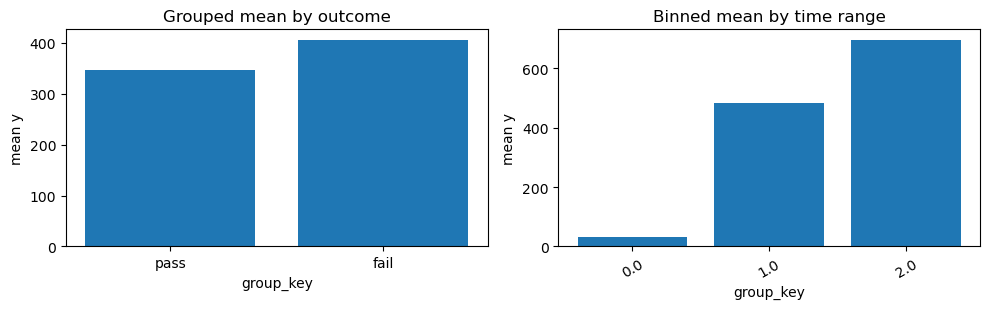

In [5]:
gb_coord = ao.group.groupby('outcome').mean()
ao_view = ao.as_dataset(copy='shallow')

time_for_bins = xr.broadcast(ao_view['time'], ao_view['y'])[0].rename('time_for_bins')
gb_bins = ao.group.groupby_bins(time_for_bins, bins=[-0.1, 0.4, 0.8, 1.2]).mean()

display_result('mean y by outcome', gb_coord, data=False)
display_result('mean y by time bins', gb_bins, data=False)

coord_df = gb_coord.as_dataset().to_dataframe().reset_index()
bin_df = gb_bins.as_dataset().to_dataframe().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
coord_key = next(col for col in coord_df.columns if col not in {'y'})
axes[0].bar(coord_df[coord_key].astype(str), coord_df['y'])
axes[0].set(title='Grouped mean by outcome', xlabel=coord_key, ylabel='mean y')

bin_key = next(col for col in bin_df.columns if col not in {'y'})
axes[1].bar(bin_df[bin_key].astype(str), bin_df['y'])
axes[1].set(title='Binned mean by time range', xlabel=bin_key, ylabel='mean y')
axes[1].tick_params(axis='x', rotation=30)
fig.tight_layout()


## Concatenate independent trajectories

`concat_batch` stacks independent AOs along a batch dimension.


In [6]:
from tal.core import BatchConcatOptions

t_a = xr.DataArray(np.linspace(0.0, 1.0, 6), dims=['sample'], name='time')
t_b = xr.DataArray(np.linspace(0.2, 1.2, 4), dims=['sample'], name='time')

a_ds = xr.Dataset(
    {'y': ('sample', np.sin(2 * np.pi * t_a.values))},
    coords={'sample': np.arange(t_a.size), 'time': ('sample', t_a.values)},
)
b_ds = xr.Dataset(
    {'y': ('sample', np.sin(2 * np.pi * t_b.values))},
    coords={'sample': np.arange(t_b.size), 'time': ('sample', t_b.values)},
)

a = tal.AnalysisObject.from_data(a_ds, sequence_dim='sample', param_coord='time')
b = tal.AnalysisObject.from_data(b_ds, sequence_dim='sample', param_coord='time')

cat_trials = a.combine.concat_batch(
    [b],
    opts=BatchConcatOptions(batch_dim='trial', batch_labels=('A', 'B'), sequence_join='outer'),
)
cat_trials.as_dataset()


<xarray.Dataset> Size: 248B
Dimensions:  (trial: 2, sample: 6)
Coordinates:
  * trial    (trial) <U1 8B 'A' 'B'
  * sample   (sample) int64 48B 0 1 2 3 4 5
    time     (trial, sample) float64 96B 0.0 0.2 0.4 0.6 ... 0.8667 1.2 nan nan
Data variables:
    y        (trial, sample) float64 96B 0.0 0.9511 0.5878 ... 0.9511 nan nan
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

## Concatenate sequence segments

`concat_sequence` appends ordered samples within the same semantic trajectory.


In [7]:
from tal.core import SequenceConcatOptions

seg1 = ao.sel(sample=slice(0, 3))
seg2 = ao.sel(sample=slice(4, 7))

appended = seg1.combine.concat_sequence(
    [seg2],
    opts=SequenceConcatOptions(batch_join='inner', overlap='error'),
)
appended.as_dataset()


<xarray.Dataset> Size: 712B
Dimensions:     (trial: 3, sample: 8)
Coordinates:
  * trial       (trial) object 24B 'A' 'B' 'C'
  * sample      (sample) int64 64B 0 1 2 3 4 5 6 7
    time        (trial, sample) float64 192B 0.0 0.1429 0.2857 ... nan nan 0.0
    group_size  (trial, sample) float64 192B 4.0 4.0 4.0 4.0 ... 3.0 3.0 3.0 nan
    outcome     (trial) object 24B 'pass' 'fail' 'pass'
    valid       (trial, sample) bool 24B True True True True ... True True False
Data variables:
    y           (trial, sample) float64 192B 0.0 14.29 28.57 ... nan nan nan
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

## Failure boundary: missing param coordinate

Sequence concatenation needs consistent sequence/param metadata when appending time-parameterized segments.


In [8]:
bad = seg2.as_dataset().drop_vars('time')
bad_ao = tal.AnalysisObject.from_data(
    bad,
    sequence_dim='sample',
    batch_dims=['trial'],
    sequence_size_coord='group_size',
    validate=False,
)

try:
    seg1.combine.concat_sequence(
        [bad_ao],
        opts=SequenceConcatOptions(batch_join='inner', overlap='error'),
    )
    print('Unexpected: concat_sequence accepted missing param coord')
except Exception as e:
    print(type(e).__name__, str(e).splitlines()[0])


SchemaError [schema.param_coord.not_found] at tal.core.param_coord.name: expected='coord in ds.coords', actual={'coord': 'time', 'coords': ['group_size', 'outcome', 'trial', 'sample']}. Fix: add the coordinate or choose an existing coord name


## Takeaways

- Ragged validity separates padded storage from valid samples.
- Grouping creates interpretable summaries across labels or bins.
- Batch concat and sequence concat change different roles.

**Exercise:** change `group_size` for trial `B` and rerun the reduction comparison.
